In [1]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

import pandas as pd
import duckdb
from pathlib import Path
from config import PROJECT_ROOT, RESEARCH_ROOT, ARTIFACTS_ROOT

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import numpy as np
from scipy import stats

import json

In [2]:
feature_groups = {
    'price_vol':['nifty_close','vix_close','underlying_daily_vol','futures_daily_vol','applicable_daily_vol'],
    'options_derived':['pcr','max_pain_dist_pct','basis','cost_of_carry','fut_chng_oi_pct'],
    'breadth':['advances','declines','adv_decl_ratio','price_band_hits','traded_value_cr','num_trades','market_cap_cr'],
    'fii_dii_positioning':['fii_fut_net_pct','client_fut_net_pct','fii_pe_net_pct','fii_net_flow_cr','dii_fut_net_pct','pro_fut_net_pct','fii_stk_fut_net_pct','client_stk_fut_net_pct'],
    'options_skew':['fii_opt_skew_pct','client_opt_skew_pct','dii_opt_skew_pct','pro_opt_skew_pct','fii_vol_opt_skew_pct','client_vol_opt_skew_pct'],
    'vol_futures_flow':['fii_vol_fut_net_pct','client_vol_fut_net_pct','pro_vol_fut_net_pct'],
    'divergence_stats':['fii_client_divergence','fii_stats_fut_net_pct','fii_stats_oi_net_cr'],
    'engineered_deltas':['vix_chg_5d','pcr_chg_5d','basis_chg_5d','max_pain_dist_chg_5d','vix_realized_spread','fii_fut_net_chg_5d'],
    'targets':['fwd_ret_1d','fwd_ret_5d','fwd_ret_20d','up_1d']
}

emission_raw = ['vix_close','underlying_daily_vol','price_band_hits','fii_stats_fut_net_pct','client_opt_skew_pct','max_pain_dist_pct','basis_chg_5d']

In [3]:
# --- load artifacts for both horizons ---
def load_artifacts(horizon_dir):
    model_df = pd.read_csv(ARTIFACTS_ROOT / horizon_dir / "backtest_inputs" / "model_df_full.csv",
                        index_col=0, parse_dates=True, float_precision='round_trip')
    with open(ARTIFACTS_ROOT / horizon_dir / "backtest_inputs" / "folds.json") as fp:
        folds_raw = json.load(fp)
    folds = [
        {'fold': f['fold'], 'train_idx': f['train_idx'], 'test_idx': f['test_idx'],
         'test_start': pd.Timestamp(f['test_start'])}
        for f in folds_raw
    ]
    with open(ARTIFACTS_ROOT / horizon_dir / "backtest_inputs" / "all_results.pkl", 'rb') as fp:
        all_results = pickle.load(fp)
    with open(ARTIFACTS_ROOT / horizon_dir / "backtest_inputs" / "garch_results.pkl", 'rb') as fp:
        garch_results = pickle.load(fp)
    return model_df, folds, all_results, garch_results

import json, pickle

model_df_5d, folds_5d, all_results_5d, garch_results_5d = load_artifacts("5d")
model_df_20d, folds_20d, all_results_20d, garch_results_20d = load_artifacts("20d")

# --- sanity checks ---
print("5D:", model_df_5d.shape, model_df_5d.index.min(), model_df_5d.index.max(), len(folds_5d), "folds")
print("20D:", model_df_20d.shape, model_df_20d.index.min(), model_df_20d.index.max(), len(folds_20d), "folds")

for name, mdf in [('5D', model_df_5d), ('20D', model_df_20d)]:
    missing = [c for c in ['nifty_close', 'garch_sigma_full', 'garch_sigma_change_full', 'hmm_state_v2'] if c not in mdf.columns]
    if missing:
        print(f"{name}: MISSING columns {missing}")
    else:
        print(f"{name}: all key columns present")

5D: (2425, 51) 2016-04-06 00:00:00 2026-07-20 00:00:00 102 folds
20D: (2411, 51) 2016-04-06 00:00:00 2026-06-29 00:00:00 101 folds
5D: all key columns present
20D: all key columns present


In [4]:
feature_cols_model = [c for c in [c for g, cols in feature_groups.items() if g != 'targets' for c in cols] if c not in emission_raw]

feat_base_5d = [c for c in feature_cols_model if c != 'nifty_close']
feat_base_full_5d = feat_base_5d + [c for c in emission_raw if c not in feat_base_5d]

feat_base_20d = [c for c in feature_cols_model if c != 'nifty_close']
feat_base_full_20d = feat_base_20d + [c for c in emission_raw if c not in feat_base_20d]

In [5]:
missing_train = [d for d in pd.to_datetime(folds_5d[0]['train_idx']) if d not in model_df_5d.index]
print(f"{len(missing_train)} train dates in fold 0 not present after filtering")

0 train dates in fold 0 not present after filtering


In [9]:
from arch import arch_model

def compute_garch_features(model_df, train_idx, test_idx):
    train_ret = model_df.loc[train_idx, 'nifty_ret_1d'].dropna() * 100

    try:
        am = arch_model(train_ret, vol='Garch', p=1, q=1, dist='t')
        res = am.fit(disp='off')
    except Exception:
        nan_train = pd.DataFrame(np.nan, index=train_idx, columns=['garch_sigma', 'garch_sigma_change'])
        nan_test = nan_train.reindex(test_idx)
        return nan_train, nan_test

    sigma_train = res.conditional_volatility / 100
    sigma_change_train = sigma_train.diff()

    train_feat = pd.DataFrame({
        'garch_sigma': sigma_train.values,
        'garch_sigma_change': sigma_change_train.values
    }, index=train_ret.index)

    fcast = res.forecast(horizon=len(test_idx), reindex=False)
    sigma_path = np.sqrt(fcast.variance.values[-1]) / 100

    test_feat = pd.DataFrame({
        'garch_sigma': sigma_path,
        'garch_sigma_change': np.diff(sigma_path, prepend=sigma_train.iloc[-1])
    }, index=test_idx[:len(sigma_path)])

    return train_feat, test_feat


def get_garch_by_fold(model_df, folds, horizon_dir, force_recompute=False):
    """
    Walk-forward GARCH features, cached as pickle (bit-exact reload — no CSV
    string round-trip involved). Also writes a CSV of the stitched-together
    test-fold sigma path purely for human inspection; that CSV is NOT re-read
    anywhere in the pipeline, so it can't reintroduce precision drift.
    """
    cache_dir = ARTIFACTS_ROOT / horizon_dir / "backtest_inputs"
    cache_path = cache_dir / "garch_by_fold_walkforward.pkl"

    model_df = model_df.copy()
    model_df['nifty_ret_1d'] = np.log(model_df['nifty_close']).diff()  # always recompute from price, never trust a saved return col

    if cache_path.exists() and not force_recompute:
        with open(cache_path, 'rb') as fp:
            garch_by_fold = pickle.load(fp)
        print(f"[{horizon_dir}] loaded cached GARCH ({len(garch_by_fold)} folds) from {cache_path}")
        return garch_by_fold, model_df

    garch_by_fold = {}
    for i, f in enumerate(folds):
        train_idx = pd.to_datetime(f['train_idx'])
        test_idx = pd.to_datetime(f['test_idx'])
        garch_by_fold[i] = compute_garch_features(model_df, train_idx, test_idx)

    cache_dir.mkdir(parents=True, exist_ok=True)
    with open(cache_path, 'wb') as fp:
        pickle.dump(garch_by_fold, fp)
    print(f"[{horizon_dir}] computed + cached GARCH ({len(garch_by_fold)} folds) -> {cache_path}")

    # human-readable side export (test-fold sigma path stitched across folds) — inspection only
    sigma = pd.Series(index=model_df.index, dtype=float)
    sigma_chg = pd.Series(index=model_df.index, dtype=float)
    for _, test_feat in garch_by_fold.values():
        sigma.loc[test_feat.index] = test_feat['garch_sigma']
        sigma_chg.loc[test_feat.index] = test_feat['garch_sigma_change']
    pd.DataFrame({'garch_sigma': sigma, 'garch_sigma_change': sigma_chg}).to_csv(
        cache_dir / "garch_walkforward_inspect.csv"
    )

    return garch_by_fold, model_df


garch_by_fold_5d, model_df_5d = get_garch_by_fold(model_df_5d, folds_5d, "5d")
garch_by_fold_20d, model_df_20d = get_garch_by_fold(model_df_20d, folds_20d, "20d")

[5d] loaded cached GARCH (102 folds) from E:\Projects\embR\artifacts\5d\backtest_inputs\garch_by_fold_walkforward.pkl
[20d] loaded cached GARCH (101 folds) from E:\Projects\embR\artifacts\20d\backtest_inputs\garch_by_fold_walkforward.pkl


In [7]:
import joblib
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from joblib import Parallel, delayed


def get_model(name):
    if name == 'xgb':
        return xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, subsample=0.8,
                                 colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, n_jobs=-1, random_state=42)
    if name == 'lgbm':
        return lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, subsample=0.8,
                                  colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, n_jobs=-1, random_state=42, verbose=-1)
    if name == 'catboost':
        return CatBoostRegressor(iterations=300, depth=4, learning_rate=0.03, l2_leaf_reg=3.0,
                                  verbose=0, random_seed=42)


def generate_oos_predictions_garch(model_df, folds, garch_by_fold, target, model_name, feat_cols,
                                    garch_cols=None, save_dir=None, exp_name=None):
    """
    Walk-forward OOS predictions. If save_dir/exp_name given, each fold's
    fitted model is persisted to save_dir/{exp_name}_fold{i}.joblib.
    """
    def _run_fold(i, f):
        train = model_df.loc[pd.to_datetime(f['train_idx'])].copy()
        test = model_df.loc[pd.to_datetime(f['test_idx'])].copy()

        feat_full = feat_cols.copy()
        if garch_cols:
            train_feat, test_feat = garch_by_fold[i]
            train = train.join(train_feat)
            test = test.join(test_feat)
            train = train.dropna(subset=garch_cols)  # GARCH fit drops leading NaN return rows
            feat_full = feat_full + garch_cols

        X_train, y_train = train[feat_full], train[target]
        X_test, y_test = test[feat_full], test[target]
        if len(X_train) < 30 or len(X_test) < 2:
            return None

        model = get_model(model_name)
        model.fit(X_train, y_train)

        if save_dir is not None:
            save_dir.mkdir(parents=True, exist_ok=True)
            joblib.dump(model, save_dir / f"{exp_name}_fold{i}.joblib")

        preds = model.predict(X_test)
        return pd.DataFrame({"fold": i, "date": X_test.index, "pred": preds, "actual": y_test.values})

    results = Parallel(n_jobs=-1)(delayed(_run_fold)(i, f) for i, f in enumerate(folds))
    rows = [r for r in results if r is not None]
    return pd.concat(rows, ignore_index=True)


def mean_fold_ic(pred_df):
    return pred_df.groupby("fold").apply(lambda g: np.corrcoef(g["pred"], g["actual"])[0, 1]).mean()

In [8]:
MODELS_DIR_5D = ARTIFACTS_ROOT / "5d" / "models"
MODELS_DIR_20D = ARTIFACTS_ROOT / "20d" / "models"
PREDS_DIR_5D = ARTIFACTS_ROOT / "5d" / "predictions"
PREDS_DIR_20D = ARTIFACTS_ROOT / "20d" / "predictions"

experiments = [
    # name,                    horizon, model_df,      folds,     garch_by_fold,     target,       model,     feat_cols,           garch_cols,                            save_dir,      preds_dir
    ("5d_lgbm_base_full_sigma", "5D", model_df_5d,  folds_5d,  garch_by_fold_5d,  'fwd_ret_5d',  'lgbm',    feat_base_full_5d,  ['garch_sigma'],                          MODELS_DIR_5D,  PREDS_DIR_5D),
    ("5d_xgb_base_full",        "5D", model_df_5d,  folds_5d,  garch_by_fold_5d,  'fwd_ret_5d',  'xgb',     feat_base_full_5d,  None,                                      MODELS_DIR_5D,  PREDS_DIR_5D),
    ("20d_catboost_base_sigma", "20D", model_df_20d, folds_20d, garch_by_fold_20d, 'fwd_ret_20d', 'catboost', feat_base_20d,    ['garch_sigma'],                          MODELS_DIR_20D, PREDS_DIR_20D),
    ("20d_xgb_base_full_sigma_delta", "20D", model_df_20d, folds_20d, garch_by_fold_20d, 'fwd_ret_20d', 'xgb', feat_base_full_20d, ['garch_sigma', 'garch_sigma_change'], MODELS_DIR_20D, PREDS_DIR_20D),
]

final_preds = {}
summary_rows = []

for name, horizon, mdf, folds, gbf, target, model_name, feat_cols, garch_cols, save_dir, preds_dir in experiments:
    preds = generate_oos_predictions_garch(
        mdf, folds, gbf, target, model_name, feat_cols,
        garch_cols=garch_cols, save_dir=save_dir, exp_name=name
    )
    ic = mean_fold_ic(preds)
    final_preds[name] = preds

    preds_dir.mkdir(parents=True, exist_ok=True)
    preds.to_parquet(preds_dir / f"{name}_oos_preds.parquet", index=False)

    summary_rows.append({"experiment": name, "horizon": horizon, "model": model_name,
                          "n_folds": preds['fold'].nunique(), "mean_fold_ic": ic})
    print(f"{name}: Mean Fold IC = {ic:.4f}  (models -> {save_dir}, preds -> {preds_dir})")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(ARTIFACTS_ROOT / "final_experiments_summary.csv", index=False)
summary_df

5d_lgbm_base_full_sigma: Mean Fold IC = 0.2200  (models -> E:\Projects\embR\artifacts\5d\models, preds -> E:\Projects\embR\artifacts\5d\predictions)
5d_xgb_base_full: Mean Fold IC = 0.2155  (models -> E:\Projects\embR\artifacts\5d\models, preds -> E:\Projects\embR\artifacts\5d\predictions)
20d_catboost_base_sigma: Mean Fold IC = 0.1946  (models -> E:\Projects\embR\artifacts\20d\models, preds -> E:\Projects\embR\artifacts\20d\predictions)
20d_xgb_base_full_sigma_delta: Mean Fold IC = 0.1954  (models -> E:\Projects\embR\artifacts\20d\models, preds -> E:\Projects\embR\artifacts\20d\predictions)


,experiment,horizon,model,n_folds,mean_fold_ic
0,5d_lgbm_base_full_sigma,5D,lgbm,102,0.220020
1,5d_xgb_base_full,5D,xgb,102,0.215503
2,20d_catboost_base_sigma,20D,catboost,101,0.194557
3,20d_xgb_base_full_sigma_delta,20D,xgb,101,0.195406


In [11]:
preds_5d_lgbm = pd.read_parquet(PREDS_DIR_5D / "5d_lgbm_base_full_sigma_oos_preds.parquet")
preds_5d_xgb = pd.read_parquet(PREDS_DIR_5D / "5d_xgb_base_full_oos_preds.parquet")

preds_20d_catboost = pd.read_parquet(PREDS_DIR_20D / "20d_catboost_base_sigma_oos_preds.parquet")
preds_20d_xgb = pd.read_parquet(PREDS_DIR_20D / "20d_xgb_base_full_sigma_delta_oos_preds.parquet")

In [ ]:
# ============================================================
# BACKTEST: daily-rebalanced long/flat (+ optional long/short)
# ============================================================

COST_BPS = 5  # per one-way trade, in basis points of notional — adjust as needed

def build_daily_returns(model_df):
    """Daily NIFTY simple returns from close price, aligned to model_df's date index."""
    ret = model_df['nifty_close'].pct_change()
    return ret

def build_signal_series(preds_df, mode='long_flat'):
    """
    preds_df: columns ['fold','date','pred','actual'], one row per trading day (rolling daily forecast).
    Returns a Series indexed by date: position in {-1, 0, 1} (or {0,1} for long_flat).
    """
    s = preds_df.drop_duplicates(subset='date').set_index('date')['pred'].sort_index()
    if mode == 'long_flat':
        position = (s > 0).astype(int)
    elif mode == 'long_short':
        position = np.sign(s).astype(int)  # -1, 0, 1 (0 only if pred exactly 0)
    else:
        raise ValueError(mode)
    return position

def run_backtest(model_df, preds_df, label, mode='long_flat', cost_bps=COST_BPS):
    daily_ret = build_daily_returns(model_df)
    position = build_signal_series(preds_df, mode=mode)

    # align position to the daily return index; position only exists on OOS test dates
    df = pd.DataFrame({'ret': daily_ret}).join(position.rename('position'), how='inner')
    df = df.dropna(subset=['ret'])
    df['position'] = df['position'].fillna(0)

    # detect position changes -> trades
    df['position_prev'] = df['position'].shift(1).fillna(0)
    df['trade'] = (df['position'] != df['position_prev']).astype(int)
    n_trades = df['trade'].sum()

    # strategy daily return: yesterday's position applied to today's return (no look-ahead)
    df['strat_ret_gross'] = df['position_prev'] * df['ret']

    # transaction cost charged only on days a trade occurs
    cost_per_trade = cost_bps / 10000.0
    df['cost'] = df['trade'] * cost_per_trade
    df['strat_ret_net'] = df['strat_ret_gross'] - df['cost']

    return df, n_trades

def compute_metrics(daily_ret_series, n_trades, periods_per_year=252):
    r = daily_ret_series.dropna()
    equity = (1 + r).cumprod()
    n_years = len(r) / periods_per_year

    cagr = equity.iloc[-1] ** (1 / n_years) - 1 if n_years > 0 else np.nan
    ann_ret = r.mean() * periods_per_year
    ann_vol = r.std() * np.sqrt(periods_per_year)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(periods_per_year) if len(downside) > 1 else np.nan
    sortino = ann_ret / downside_vol if downside_vol and downside_vol > 0 else np.nan

    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    hit_rate = (r > 0).mean()
    avg_trade_ret = r[r != 0].mean() if (r != 0).any() else np.nan

    return {
        'CAGR': cagr, 'Ann.Return': ann_ret, 'Ann.Vol': ann_vol,
        'Sharpe': sharpe, 'Sortino': sortino, 'MaxDD': max_dd, 'Calmar': calmar,
        'HitRate': hit_rate, 'N_Trades': n_trades, 'AvgDailyRet': avg_trade_ret,
        'FinalEquity': equity.iloc[-1]
    }, equity

# --- benchmark: buy and hold, over the union of both backtest windows ---
def buy_and_hold_metrics(model_df, start_date, end_date):
    r = build_daily_returns(model_df).loc[start_date:end_date].dropna()
    equity = (1 + r).cumprod()
    m, eq = compute_metrics(r, n_trades=1)  # 1 trade: initial entry
    return m, eq

# --- run all four models ---
specs = {
    '5D_LightGBM+sigma': (model_df_5d, preds_5d_lgbm),
    '5D_XGBoost(full)':  (model_df_5d, preds_5d_xgb),
    '20D_CatBoost+sigma': (model_df_20d, preds_20d_catboost),
    '20D_XGBoost(full)+sigma+delta': (model_df_20d, preds_20d_xgb),
}

results_summary = {}
equity_curves = {}

for label, (mdf, preds) in specs.items():
    df_bt, n_trades = run_backtest(mdf, preds, label, mode='long_flat')
    metrics, equity = compute_metrics(df_bt['strat_ret_net'], n_trades)
    results_summary[label] = metrics
    equity_curves[label] = equity

    # also compute gross (no-cost) for comparison
    metrics_gross, _ = compute_metrics(df_bt['strat_ret_gross'], n_trades)
    results_summary[f'{label} (gross, no cost)'] = metrics_gross

# --- benchmark over each horizon's actual backtest window ---
bh_5d, eq_bh_5d = buy_and_hold_metrics(model_df_5d, preds_5d_xgb['date'].min(), preds_5d_xgb['date'].max())
bh_20d, eq_bh_20d = buy_and_hold_metrics(model_df_20d, preds_20d_xgb['date'].min(), preds_20d_xgb['date'].max())
results_summary['BuyHold_5D_window'] = bh_5d
results_summary['BuyHold_20D_window'] = bh_20d
equity_curves['BuyHold_5D_window'] = eq_bh_5d
equity_curves['BuyHold_20D_window'] = eq_bh_20d

summary_df = pd.DataFrame(results_summary).T
pd.set_option('display.float_format', '{:.4f}'.format)
print(summary_df)

NameError: name 'position_series' is not defined

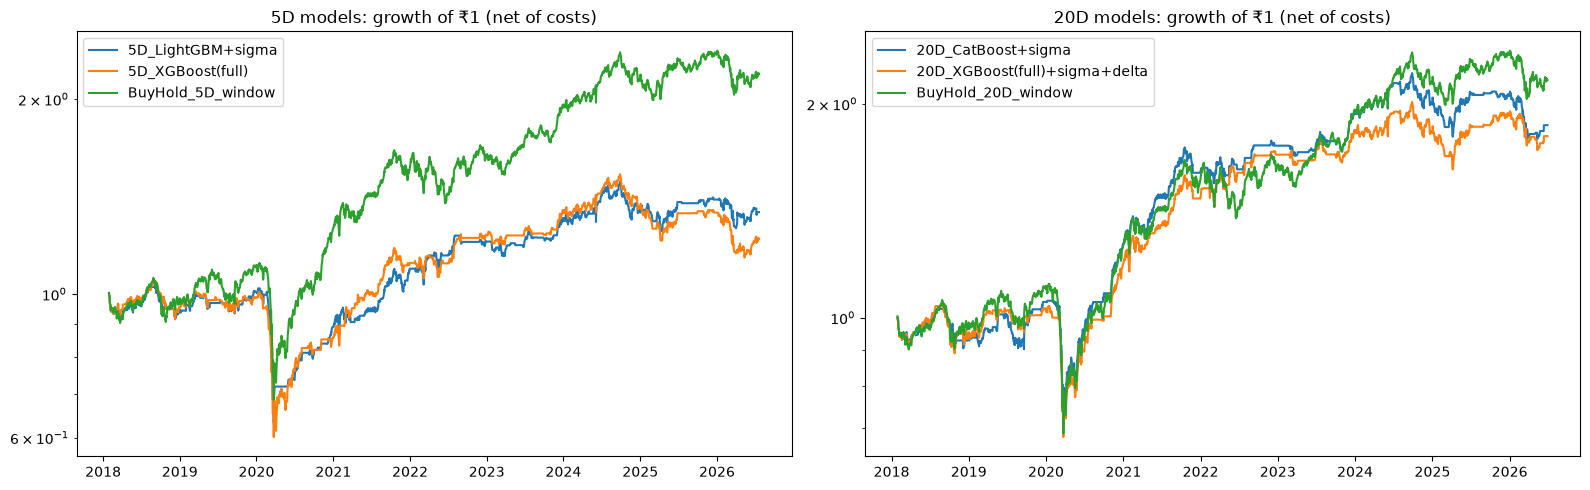

In [15]:
# --- equity curve plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for label in ['5D_LightGBM+sigma', '5D_XGBoost(full)', 'BuyHold_5D_window']:
    axes[0].plot(equity_curves[label].index, equity_curves[label].values, label=label)
axes[0].set_title('5D models: growth of ₹1 (net of costs)')
axes[0].legend(); axes[0].set_yscale('log')

for label in ['20D_CatBoost+sigma', '20D_XGBoost(full)+sigma+delta', 'BuyHold_20D_window']:
    axes[1].plot(equity_curves[label].index, equity_curves[label].values, label=label)
axes[1].set_title('20D models: growth of ₹1 (net of costs)')
axes[1].legend(); axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots/backtest/equity_curves.png', dpi=120)
plt.show()

In [19]:
# ============================================================
# FIX 1: HitRate — only count invested days
# ============================================================
def compute_metrics(daily_ret_series, position_prev_series, n_trades, periods_per_year=252):
    r = daily_ret_series.dropna()
    equity = (1 + r).cumprod()
    n_years = len(r) / periods_per_year

    cagr = equity.iloc[-1] ** (1 / n_years) - 1 if n_years > 0 else np.nan
    ann_ret = r.mean() * periods_per_year
    ann_vol = r.std() * np.sqrt(periods_per_year)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(periods_per_year) if len(downside) > 1 else np.nan
    sortino = ann_ret / downside_vol if downside_vol and downside_vol > 0 else np.nan

    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    # HitRate: only over days with an actual position (invested days)
    invested_mask = position_prev_series.reindex(r.index).fillna(0) != 0
    invested_ret = r[invested_mask]
    hit_rate = (invested_ret > 0).mean() if len(invested_ret) > 0 else np.nan
    pct_invested = invested_mask.mean()

    avg_trade_ret = invested_ret.mean() if len(invested_ret) > 0 else np.nan

    return {
        'CAGR': cagr, 'Ann.Return': ann_ret, 'Ann.Vol': ann_vol,
        'Sharpe': sharpe, 'Sortino': sortino, 'MaxDD': max_dd, 'Calmar': calmar,
        'HitRate': hit_rate, 'PctTimeInvested': pct_invested,
        'N_Trades': n_trades, 'AvgInvestedDayRet': avg_trade_ret,
        'FinalEquity': equity.iloc[-1]
    }, equity


# ============================================================
# FIX 2: threshold + position sizing, threshold picked on TRAIN folds only
# ============================================================
def build_signal_with_threshold(preds_df, folds, mode='binary', threshold_rule='zero',
                                 weighting='none', vol_lookback=20, model_df=None):
    """
    mode: 'long_flat' or 'long_short'
    threshold_rule: 'zero', 'fixed_25bps', 'fixed_50bps', 'rolling_median', 'rolling_p75'
    weighting: 'none' (binary), 'linear' (pred/max_abs_pred, per-fold), 'tanh' (tanh(pred/rolling_sigma))
    Threshold and any scaling stats are computed PER FOLD using only that fold's train predictions
    (via the fold's train_idx return series distribution), then applied unchanged to that fold's test predictions.
    """
    preds_df = preds_df.sort_values('date').drop_duplicates(subset='date').set_index('date')
    out = pd.Series(0.0, index=preds_df.index)

    for f in folds:
        test_dates = pd.to_datetime(f['test_idx'])
        test_dates = test_dates[test_dates.isin(preds_df.index)]
        if len(test_dates) == 0:
            continue
        fold_preds = preds_df.loc[test_dates, 'pred']

        # --- threshold: derived from TRAIN fold's own historical prediction distribution ---
        train_dates = pd.to_datetime(f['train_idx'])
        train_dates = train_dates[train_dates.isin(preds_df.index)]
        train_preds = preds_df.loc[train_dates, 'pred'] if len(train_dates) > 0 else fold_preds

        if threshold_rule == 'zero':
            thresh = 0.0
        elif threshold_rule == 'fixed_25bps':
            thresh = 0.0025
        elif threshold_rule == 'fixed_50bps':
            thresh = 0.0050
        elif threshold_rule == 'rolling_median':
            thresh = train_preds.abs().median()
        elif threshold_rule == 'rolling_p75':
            thresh = train_preds.abs().quantile(0.75)
        else:
            raise ValueError(threshold_rule)

        active = fold_preds.abs() > thresh

        if weighting == 'none':
            w = np.sign(fold_preds) if mode == 'long_short' else (fold_preds > 0).astype(float)
            w = w.where(active, 0.0)
        elif weighting == 'linear':
            max_abs = train_preds.abs().max()
            max_abs = max_abs if max_abs > 0 else 1.0
            w = (fold_preds / max_abs).clip(-1, 1)
            if mode == 'long_flat':
                w = w.clip(lower=0)
            w = w.where(active, 0.0)
        elif weighting == 'tanh':
            sigma = train_preds.std()
            sigma = sigma if sigma > 0 else 1.0
            w = np.tanh(fold_preds / sigma).clip(-1, 1)
            if mode == 'long_flat':
                w = w.clip(lower=0)
            w = w.where(active, 0.0)
        else:
            raise ValueError(weighting)

        out.loc[test_dates] = w.values

    return out


def run_backtest_v2(model_df, position_series, cost_bps=COST_BPS):
    daily_ret = build_daily_returns(model_df)
    df = pd.DataFrame({'ret': daily_ret}).join(position_series.rename('position'), how='inner')
    df = df.dropna(subset=['ret'])
    df['position'] = df['position'].fillna(0)
    df['position_prev'] = df['position'].shift(1).fillna(0)

    # turnover-based cost: proportional to change in position size (handles partial sizing correctly)
    df['position_change'] = (df['position'] - df['position_prev']).abs()
    n_trades = (df['position_change'] > 1e-9).sum()

    cost_per_unit = cost_bps / 10000.0
    df['strat_ret_gross'] = df['position_prev'] * df['ret']
    df['cost'] = df['position_change'] * cost_per_unit
    df['strat_ret_net'] = df['strat_ret_gross'] - df['cost']

    return df, n_trades


# ============================================================
# run the full grid: binary vs threshold vs sizing, for all 4 models
# ============================================================
variant_configs = {
    'binary_zero':        dict(mode='long_flat', threshold_rule='zero',          weighting='none'),
    'binary_25bps':       dict(mode='long_flat', threshold_rule='fixed_25bps',   weighting='none'),
    'binary_50bps':       dict(mode='long_flat', threshold_rule='fixed_50bps',   weighting='none'),
    'binary_rollmed':     dict(mode='long_flat', threshold_rule='rolling_median',weighting='none'),
    'binary_rollp75':     dict(mode='long_flat', threshold_rule='rolling_p75',   weighting='none'),
    'sized_linear_zero':  dict(mode='long_flat', threshold_rule='zero',          weighting='linear'),
    'sized_tanh_zero':    dict(mode='long_flat', threshold_rule='zero',          weighting='tanh'),
    'sized_tanh_p75':     dict(mode='long_flat', threshold_rule='rolling_p75',   weighting='tanh'),
}

model_specs = {
    '5D_LightGBM+sigma':            (model_df_5d, preds_5d_lgbm, folds_5d),
    '5D_XGBoost(full)':             (model_df_5d, preds_5d_xgb, folds_5d),
    '20D_CatBoost+sigma':           (model_df_20d, preds_20d_catboost, folds_20d),
    '20D_XGBoost(full)+sigma+delta':(model_df_20d, preds_20d_xgb, folds_20d),
}

all_results = {}
all_equity = {}

for model_label, (mdf, preds, folds) in model_specs.items():
    for variant_name, cfg in variant_configs.items():
        pos = build_signal_with_threshold(preds, folds, **cfg)
        df_bt, n_trades = run_backtest_v2(mdf, pos)
        metrics, equity = compute_metrics(df_bt['strat_ret_net'], df_bt['position_prev'], n_trades)
        key = f'{model_label} | {variant_name}'
        all_results[key] = metrics
        all_equity[key] = equity

results_grid = pd.DataFrame(all_results).T
print(results_grid[['CAGR','Sharpe','MaxDD','Calmar','HitRate','PctTimeInvested','N_Trades']])

                                                     CAGR  Sharpe   MaxDD  \
5D_LightGBM+sigma | binary_zero                    0.0374  0.3377 -0.3864   
5D_LightGBM+sigma | binary_25bps                   0.0371  0.3357 -0.3864   
5D_LightGBM+sigma | binary_50bps                   0.0379  0.3413 -0.3864   
5D_LightGBM+sigma | binary_rollmed                -0.0107 -0.0350 -0.3698   
5D_LightGBM+sigma | binary_rollp75                 0.0106  0.1591 -0.3351   
5D_LightGBM+sigma | sized_linear_zero             -0.0153 -0.1501 -0.3154   
5D_LightGBM+sigma | sized_tanh_zero                0.0039  0.0912 -0.3451   
5D_LightGBM+sigma | sized_tanh_p75                 0.0069  0.1223 -0.3310   
5D_XGBoost(full) | binary_zero                     0.0250  0.2426 -0.4255   
5D_XGBoost(full) | binary_25bps                    0.0248  0.2411 -0.4255   
5D_XGBoost(full) | binary_50bps                    0.0269  0.2558 -0.4379   
5D_XGBoost(full) | binary_rollmed                 -0.0111 -0.0364 -0.3631   

In [20]:
# ============================================================
# Vol-targeted, horizon-matched signal with hysteresis
# ============================================================

def build_advanced_signal(preds_df, folds, model_df, horizon_days,
                            target_ann_vol=0.12, vol_lookback=60,
                            entry_z=0.5, exit_z=0.1, max_leverage=1.5,
                            mode='long_flat'):
    """
    All parameters below are FIXED, economically-motivated choices (not fit on test data):
    - EWMA span = horizon_days (matches the model's own prediction horizon)
    - vol_lookback, target_ann_vol: standard vol-targeting overlay constants
    - entry_z/exit_z: hysteresis band, in units of trailing signal z-score

    Any statistic that touches "the future" is trailing-only (rolling on past days),
    so there is no leakage even though we don't refit these per fold.
    """
    preds_df = preds_df.sort_values('date').drop_duplicates(subset='date').set_index('date')
    daily_ret = build_daily_returns(model_df)

    # --- 1. horizon-matched smoothing of the raw daily prediction ---
    smoothed_pred = preds_df['pred'].ewm(span=horizon_days, min_periods=max(3, horizon_days//2)).mean()

    # --- 2. confidence z-score: smoothed pred relative to its OWN trailing distribution ---
    # (expanding/rolling window uses only past values up to t, no lookahead)
    roll_std = smoothed_pred.rolling(window=252, min_periods=60).std()
    z = (smoothed_pred / roll_std).clip(-4, 4)

    # --- 3. trailing realized vol for vol-targeting (purely backward-looking) ---
    realized_vol = daily_ret.reindex(smoothed_pred.index).rolling(vol_lookback, min_periods=20).std() * np.sqrt(252)
    vol_scale = (target_ann_vol / realized_vol).clip(upper=max_leverage)

    # --- 4. directional weight with hysteresis (state machine, sequential) ---
    direction = np.zeros(len(z))
    state = 0  # 0 = flat, 1 = long, -1 = short
    z_vals = z.values
    for i in range(len(z_vals)):
        zi = z_vals[i]
        if np.isnan(zi):
            direction[i] = state
            continue
        if state <= 0 and zi > entry_z:
            state = 1
        elif state >= 0 and zi < -entry_z and mode == 'long_short':
            state = -1
        elif state == 1 and zi < exit_z:
            state = 0
        elif state == -1 and zi > -exit_z:
            state = 0
        direction[i] = state

    direction = pd.Series(direction, index=z.index)
    if mode == 'long_flat':
        direction = direction.clip(lower=0)

    # --- final position: direction * vol-targeted exposure ---
    position = (direction * vol_scale).clip(-max_leverage, max_leverage).fillna(0)
    return position


# --- run for all four models, long/flat primary ---
horizon_map = {
    '5D_LightGBM+sigma': 5, '5D_XGBoost(full)': 5,
    '20D_CatBoost+sigma': 20, '20D_XGBoost(full)+sigma+delta': 20
}

advanced_results = {}
advanced_equity = {}

for model_label, (mdf, preds, folds) in model_specs.items():
    h = horizon_map[model_label]
    pos = build_advanced_signal(preds, folds, mdf, horizon_days=h, mode='long_flat')
    df_bt, n_trades = run_backtest_v2(mdf, pos)
    metrics, equity = compute_metrics(df_bt['strat_ret_net'], df_bt['position_prev'], n_trades)
    advanced_results[f'{model_label} | vol_target_smoothed'] = metrics
    advanced_equity[f'{model_label} | vol_target_smoothed'] = equity

adv_df = pd.DataFrame(advanced_results).T
print(adv_df[['CAGR','Sharpe','MaxDD','Calmar','HitRate','PctTimeInvested','N_Trades']])

                                                     CAGR  Sharpe   MaxDD  \
5D_LightGBM+sigma | vol_target_smoothed            0.0242  0.2994 -0.2278   
5D_XGBoost(full) | vol_target_smoothed             0.0237  0.2948 -0.2283   
20D_CatBoost+sigma | vol_target_smoothed           0.0379  0.4298 -0.2641   
20D_XGBoost(full)+sigma+delta | vol_target_smoo... 0.0535  0.5740 -0.2360   

                                                    Calmar  HitRate  \
5D_LightGBM+sigma | vol_target_smoothed             0.1062   0.5325   
5D_XGBoost(full) | vol_target_smoothed              0.1040   0.5423   
20D_CatBoost+sigma | vol_target_smoothed            0.1434   0.5428   
20D_XGBoost(full)+sigma+delta | vol_target_smoo...  0.2266   0.5494   

                                                    PctTimeInvested  N_Trades  
5D_LightGBM+sigma | vol_target_smoothed                      0.4006  844.0000  
5D_XGBoost(full) | vol_target_smoothed                       0.3851  819.0000  
20D_CatBoost+sigma